# Lab 6 — Control theory on cellular dynamics (`jaxctrl`)

*Sixth session of the [`notebooks/` course](README.md) on computational synthetic morphology
(after [Lab 5 — Hypergraph Neural ODEs](05_hypergraph_neural_odes.ipynb); see also
[Lab 7 — Structural identifiability](07_structural_identifiability.ipynb)).*

Lab 5 gave us a **flow** — $\dot x = f(x)$ — and a Waddington landscape with basins for cell types.
This lab adds the **input**: $\dot x = f(x) + Bu$, a *controlled* system, and asks the engineering
questions. (i) **Reachability/controllability** — can a chosen set of perturbation handles (which
TFs you can dose / activate optogenetically / knock down) steer the whole network anywhere? (ii)
**Driver nodes** — what is the *minimum* set of handles, and which ones have the most *leverage*?
(iii) **Optimal control** — given a target state, the cheapest input that gets there (minimum-energy
control; LQR feedback). This is the **`jaxctrl`** layer of the project — the controller-synthesis
piece that sits next to the plant model (Lab 5), the system identification (the regulome itself; Lab
6's SBI), and the observability/decomposition layer (Labs 4 & 7).

The headline you'll arrive at — the *control* mirror of Lab 7's *observability* result: **the
curated master regulators do not control (or observe) the TF network on their own.** From the 7 key
TFs the Kalman controllability rank is far below 200 (≈9–30 depending on the numerical tolerance —
the controllability matrix's singular values decay smoothly); you need feedback on *many more*
handles (or the full state) to steer reliably. That's why Lab 8 poses optimal control on the
*learned* flow with feedback, not open-loop on a handful of master TFs — and it's the same fact,
seen from the input side, that makes the regulome's SBI posterior a ridge rather than a point.

We work in two registers: **linear network control** on a TF co-regulation graph built from the
Pando regulome (mirroring `scripts/benchmark_network_control.py`), implemented here in pure
JAX/SciPy so the notebook runs without `jaxctrl`; and pointers to the **three `jaxctrl` worked
examples** (`examples/repressilator_control_demo.py`, `examples/irma_sindy_lqr.ipynb`,
`examples/grn_hypergraph_drivers.ipynb`) for the nonlinear / SINDy-surrogate / hypergraph-driver
versions. **Needs:** `numpy`, `scipy`, `jax`, `matplotlib`; optionally `jaxctrl` (soft import).
Reads `data/processed/{incidence,tf_names,gene_names,tf_gene_indices,key_tf_indices,temporal_expression}.*`
+ `figures/network_control_results.json`; falls back to a tiny synthetic 2-state system.

**Refs:** Liu, Slotine & Barabási 2011 (structural controllability of complex networks); Gu et al.
2015 (controllability of structural brain networks — average vs modal); Pasqualetti, Zampieri &
Bullo 2014 (controllability metrics); Yan et al. 2017 (network control principles, the
control–robustness trade-off); Pezzulo & Levin 2016 / Levin 2022 (the "anatomical compiler" framing).

In [1]:
import json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import scipy.linalg as sla

jax.config.update("jax_enable_x64", True)          # control algebra wants the precision
rng = np.random.default_rng(0)

def _find(*parts):
    here = Path.cwd()
    for base in [here, *here.parents]:
        p = base.joinpath(*parts)
        if p.exists():
            return p
    return None
def _loadjson(*parts):
    p = _find(*parts);  return json.loads(p.read_text()) if p else None

try:
    import jaxctrl
    HAVE_JAXCTRL = True
except Exception:
    HAVE_JAXCTRL = False

# ---- build the linear TF co-regulation network from the Pando regulome ----------------------
def tf_network(inc, n_tf_keep=200, knn=8, eps=1e-3):
    """A = -(L_sym + eps*I) of a sparse Jaccard-kNN graph over the top-N regulons (Hurwitz)."""
    tc   = inc.sum(0)
    kept = np.argsort(-tc)[:min(n_tf_keep, inc.shape[1])]
    H    = inc[:, kept].astype(np.float64)
    inter = H.T @ H
    sizes = np.diag(inter).copy()
    union = sizes[:, None] + sizes[None, :] - inter
    J = np.where(union > 0, inter / np.maximum(union, 1e-9), 0.0); np.fill_diagonal(J, 0.0)
    k = len(kept); knn = max(1, min(knn, k - 1))
    W = np.zeros_like(J)
    for i in range(k):
        nbr = np.argpartition(-J[i], knn)[:knn]; W[i, nbr] = J[i, nbr]
    W = np.maximum(W, W.T)
    deg = W.sum(1); dinv = np.where(deg > 0, 1.0 / np.sqrt(deg + 1e-9), 0.0)
    L = np.eye(k) - (dinv[:, None] * W) * dinv[None, :]
    return -(L + eps * np.eye(k)), kept, deg

PROC = _find("data", "processed")
HAVE_REAL = PROC is not None and (PROC / "incidence.npy").exists()
if HAVE_REAL:
    incidence  = np.load(PROC / "incidence.npy").astype(np.float64)
    tf_names   = json.loads((PROC / "tf_names.json").read_text())
    gene_names = json.loads((PROC / "gene_names.json").read_text())
    tf_gene    = json.loads((PROC / "tf_gene_indices.json").read_text()) if (PROC / "tf_gene_indices.json").exists() else {}
    key_tf     = json.loads((PROC / "key_tf_indices.json").read_text()) if (PROC / "key_tf_indices.json").exists() else {}
    temporal   = np.load(PROC / "temporal_expression.npy").astype(np.float64) if (PROC / "temporal_expression.npy").exists() else None
    A_np, kept, deg = tf_network(incidence, n_tf_keep=200)
    kept_names = [tf_names[i] for i in kept]
    name_to_local = {nm: j for j, nm in enumerate(kept_names)}
    drivers_local = sorted(name_to_local[nm] for nm in key_tf if nm in name_to_local)
    if not drivers_local:
        drivers_local = sorted(np.argsort(-deg)[:7].tolist())
    driver_names = [kept_names[j] for j in drivers_local]
    SRC = "Pando organoid regulome → top-200-regulon Jaccard-kNN TF network"
else:
    print("[note] data/processed/ not found — tiny synthetic 2-state plant ẋ = [[-1,1],[0,-2]]x + [[1],[0]]u.")
    A_np = np.array([[-1.0, 1.0], [0.0, -2.0]]); kept = np.arange(2)
    kept_names = ["x1", "x2"]; drivers_local = [0]; driver_names = ["x1"]; deg = np.array([1.0, 1.0])
    temporal = None; tf_gene = {}; key_tf = {"x1": 0}
    SRC = "synthetic 2-state plant"

n = A_np.shape[0]
net_json = _loadjson("figures", "network_control_results.json")

print(f"plant                 : {SRC}")
print(f"  state dim n         : {n}   (A Hurwitz: max Re λ = {np.linalg.eigvals(A_np).real.max():.3f})")
print(f"  driver/handle TFs   : {len(drivers_local)} → {driver_names}")
print(f"committed jaxctrl run : {'figures/network_control_results.json loaded' if net_json else 'absent'}   | jaxctrl importable: {HAVE_JAXCTRL}")

plant                 : Pando organoid regulome → top-200-regulon Jaccard-kNN TF network
  state dim n         : 200   (A Hurwitz: max Re λ = -0.001)
  driver/handle TFs   : 7 → ['NEUROD6', 'GLI3', 'FOXG1', 'DLX2', 'DLX1', 'TBR1', 'EOMES']
committed jaxctrl run : figures/network_control_results.json loaded   | jaxctrl importable: True


## 1. Linear network control in five objects

For a linear time-invariant plant $\dot x = Ax + Bu$ ($x\in\mathbb R^n$ the gene/TF state, $u\in
\mathbb R^m$ the inputs, $B$ picking out which states you can push), the toolkit:

1. **Controllability matrix** $\mathcal C = [\,B\;\;AB\;\;A^2B\;\cdots\;A^{n-1}B\,]$. The reachable
   subspace is $\operatorname{range}(\mathcal C)$; the system is **controllable** iff
   $\operatorname{rank}\mathcal C = n$ (Kalman). Anything in the *left* nullspace of $\mathcal C$ is
   a direction you simply cannot move with these inputs.
2. **Controllability Gramian** $W_T = \int_0^T e^{A\tau}BB^{\top}e^{A^{\top}\tau}\,d\tau$ (for
   Hurwitz $A$, $W_\infty$ solves the Lyapunov equation $AW + WA^{\top} + BB^{\top}=0$). It is the
   *quantitative* version: $\operatorname{tr}W_T$ ≈ "**average controllability**" (how reachable the
   typical direction is), $\lambda_{\min}(W_T)$ ≈ "**modal / boundary controllability**" (how
   reachable the *hardest* direction is — Gu et al. 2015).
3. **Minimum-energy control** to steer $x_0 \!\to\! x_f$ over $[0,T]$:
   $E^\star = (x_f - e^{AT}x_0)^{\top} W_T^{-1} (x_f - e^{AT}x_0)$. If $W_T$ is (near-)singular in
   the $x_f$ direction, the target is (effectively) unreachable and $E^\star \to \infty$.
4. **LQR** — instead of hitting a point exactly, regulate $y = x - x_f$ to $0$ minimising
   $\int (y^{\top}Qy + u^{\top}Ru)\,dt$: solve the algebraic Riccati equation $A^{\top}X + XA -
   XBR^{-1}B^{\top}X + Q = 0$, take $u = -Ky$ with $K = R^{-1}B^{\top}X$; the **cost-to-go** from
   $y_0$ is $y_0^{\top}Xy_0$.
5. **Driver nodes / structural controllability** (Liu–Slotine–Barabási 2011): the *minimum number of
   inputs* to make a network structurally controllable equals $n$ minus the size of a maximum
   matching in the digraph of $A$. "Which TFs, and how few?" is a matching problem.

These are short to implement; we do so below (and use `jaxctrl` if it's importable). The
*nonlinear* versions — linearise the Lab-5 ODE, or fit a SINDy/Koopman linear surrogate, then run
this toolkit — are the `jaxctrl` example notebooks (§5).

In [2]:
# ---- pure-JAX/SciPy implementations of the five objects (jaxctrl-compatible) ----------------
def ctrb_matrix(A, B):
    n = A.shape[0]; cols = [B]; M = B
    for _ in range(n - 1):
        M = A @ M; cols.append(M)
    return np.hstack(cols)

def ctrb_rank(A, B, rel_tol=None):
    """Numerical rank of [B AB ... A^{n-1}B].  rel_tol: drop σ ≤ σ_max·n·rel_tol
    (default: float64 eps; pass rel_tol≈1.2e-7 for the float32 tolerance the committed run used)."""
    s = np.linalg.svd(ctrb_matrix(A, B), compute_uv=False)
    eps = np.finfo(float).eps if rel_tol is None else rel_tol
    return int((s > s[0] * A.shape[0] * eps).sum())

def is_controllable(A, B):
    return ctrb_rank(A, B) == A.shape[0]

def _expm_grid(A, T, K=60):
    """Φ_k = expm(A·τ_k), τ_k = (k+½)T/K (midpoints), plus Φ_T = expm(A·T)."""
    dt = T / K
    tau = (np.arange(K) + 0.5) * dt
    # incremental: Φ_{k+1} = Φ_k · expm(A·dt) starting from expm(A·dt/2)
    step = sla.expm(A * dt)
    Phi = sla.expm(A * (dt / 2.0))
    grids = []
    for _ in range(K):
        grids.append(Phi.copy()); Phi = Phi @ step
    return np.stack(grids), dt, sla.expm(A * T)

def gramian_T(A, B, T, K=60, _grids=None):
    grids, dt, _ = _grids if _grids is not None else _expm_grid(A, T, K)
    W = np.zeros((A.shape[0], A.shape[0]))
    for Phi in grids:
        PB = Phi @ B; W += PB @ PB.T
    return W * dt

def avg_controllability_all(A, T, K=60):
    """tr(W_T(e_i)) for every single-node input i, all at once: Σ_k ‖Φ_k[:,i]‖² · dt."""
    grids, dt, _ = _expm_grid(A, T, K)
    return (np.stack([(Phi ** 2).sum(0) for Phi in grids]).sum(0)) * dt, grids, dt

def min_energy(A, B, x0, xf, T, K=60, _grids=None):
    grids, dt, PhiT = _grids if _grids is not None else _expm_grid(A, T, K)
    W = gramian_T(A, B, T, _grids=(grids, dt, PhiT))
    delta = xf - PhiT @ x0
    lam_min = float(np.linalg.eigvalsh((W + W.T) / 2)[0])
    # if the Gramian doesn't span δ, the "energy" is an ill-conditioned pinv artefact → flag it
    Wp = np.linalg.pinv(W, rcond=1e-10)
    e = float(delta @ Wp @ delta)
    return (abs(e) if (np.isfinite(e) and lam_min > 1e-9) else None), lam_min, W

def lqr(A, B, Q, R):
    X = sla.solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ X)
    return K, X

def min_driver_nodes(A, thr=1e-9):
    """Liu–Slotine–Barabási structural N_D = n − (max matching in the digraph of A, self-loops excluded).
    NB this is a *generic* property of the topology (arbitrary edge weights); our specific A is a
    Laplacian — highly non-generic weights — so its *exact* Kalman rank can be far below what
    genericity promises (see §2)."""
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import maximum_bipartite_matching
    Adj = (np.abs(A) > thr).astype(int); np.fill_diagonal(Adj, 0)               # off-diagonal structure only
    m = maximum_bipartite_matching(csr_matrix(Adj), perm_type="column")
    return max(1, A.shape[0] - int((m >= 0).sum()))

# ---- sanity check on a textbook 2-state system ----------------------------------------------
A2 = np.array([[0.0, 1.0], [-2.0, -3.0]]); B2 = np.array([[0.0], [1.0]])
print(f"toy 2-state ẋ=Ax+Bu :  ctrb rank = {ctrb_rank(A2, B2)}/2  (controllable = {is_controllable(A2, B2)})")
Kt, Xt = lqr(A2, B2, np.eye(2), np.array([[1.0]]))
print(f"                       LQR gain K = {Kt.ravel().round(3)},  cost-to-go from [1,0] = {(np.array([1,0]) @ Xt @ np.array([1,0])):.3f}")
print(f"                       min driver nodes (structural) = {min_driver_nodes(A2)}")
if HAVE_JAXCTRL:
    print(f"  (jaxctrl present: jaxctrl.is_controllable(A2,B2) = {bool(jaxctrl.is_controllable(jnp.asarray(A2), jnp.asarray(B2)))})")

toy 2-state ẋ=Ax+Bu :  ctrb rank = 2/2  (controllable = True)
                       LQR gain K = [0.236 0.236],  cost-to-go from [1,0] = 1.236
                       min driver nodes (structural) = 1
  (jaxctrl present: jaxctrl.is_controllable(A2,B2) = True)


## 2. Can the master regulators control the network?

Build $\dot x = Ax + Bu$ on the 200-TF co-regulation graph, with $B$ selecting the curated key TFs
(GLI3, FOXG1, TBR1, DLX1, DLX2, EOMES, NEUROD6 — those that survive the top-200-by-target-count
filter) as the inputs. Kalman rank?

This is the **dual** of Lab 7's observability finding. Controllability of $(A,B)$ ⇔ observability
of $(A^{\top}, B^{\top})$ — and Lab 7 already showed the regulome's linear surrogate is *not
observable* from the master regulators alone (which is *why* the SBI posterior is ridge-shaped).
Here we see the same wall from the actuator side: a few master TFs reach only a low-dimensional
slice of the 200-dim state.

In [3]:
B_drivers = np.eye(n)[:, drivers_local]                       # (n, m)
rank64 = ctrb_rank(A_np, B_drivers)                            # float64 tolerance
rank32 = ctrb_rank(A_np, B_drivers, rel_tol=1.2e-7)            # the float32 tol the committed run used
print(f"Kalman controllability of the {n}-TF network from the {len(drivers_local)}-TF master set:")
print(f"  rank(𝒞) ≈ {rank32}–{rank64} / {n}   (float32 tol → {rank32}; float64 tol → {rank64})   →   fully controllable: False")
print(f"  the singular values of 𝒞 decay smoothly (Hurwitz network), so 'the rank' is tolerance-dependent —")
print(f"  but it is *far* below {n} either way: only ~{rank64} of {n} state directions are reachable from these handles.")
if net_json and "controllability" in net_json:
    cj = net_json["controllability"]
    print(f"\n  committed jaxctrl run: rank {cj.get('key_tf_set_rank')}/{cj.get('n')}, controllable={cj.get('key_tf_set_controllable')}"
          f"  (= our float32-tolerance {rank32}{'  ✓' if cj.get('key_tf_set_rank')==rank32 else ''})")
    print(f"  min driver nodes (structural, hgx, from the json): {cj.get('min_driver_nodes_hgx')}")
print(f"\n  structural min-driver-nodes (Liu–Slotine–Barabási, this graph's topology): N_D = {min_driver_nodes(A_np)} / {n}")
print(f"  ⚠ that's a *generic* count (arbitrary edge weights); our A is a Laplacian — non-generic weights —")
print(f"    so the *exact* Kalman rank ({rank64}) is far below what genericity (N_D={min_driver_nodes(A_np)}) would promise. Structural ≠ exact controllability.")
print("  → the master regulators are a *specification* set (they pin down identity), not a *control* set.")
print("    The duality with Lab 7: not observable from the masters  ⇔  not controllable from the masters.")

Kalman controllability of the 200-TF network from the 7-TF master set:
  rank(𝒞) ≈ 9–32 / 200   (float32 tol → 9; float64 tol → 32)   →   fully controllable: False
  the singular values of 𝒞 decay smoothly (Hurwitz network), so 'the rank' is tolerance-dependent —
  but it is *far* below 200 either way: only ~32 of 200 state directions are reachable from these handles.

  committed jaxctrl run: rank 9/200, controllable=False  (= our float32-tolerance 9  ✓)
  min driver nodes (structural, hgx, from the json): None

  structural min-driver-nodes (Liu–Slotine–Barabási, this graph's topology): N_D = 1 / 200
  ⚠ that's a *generic* count (arbitrary edge weights); our A is a Laplacian — non-generic weights —
    so the *exact* Kalman rank (32) is far below what genericity (N_D=1) would promise. Structural ≠ exact controllability.
  → the master regulators are a *specification* set (they pin down identity), not a *control* set.
    The duality with Lab 7: not observable from the masters  ⇔  not

## 3. Control leverage per TF — and the surprise

For each single TF $i$, the finite-horizon Gramian $W_i = W_T(A, e_i)$ summarises how much a
single-handle intervention on $i$ steers the whole network: $\operatorname{tr}W_i$ = average
controllability, $\lambda_{\min}W_i$ = modal controllability (Gu et al. 2015). Rank the 200 TFs by
average controllability. The surprise (and it's robust — `figures/network_control_results.json`
finds the same): the **highest-leverage single TFs are *not* the curated master regulators**. Only
EOMES sneaks into the top 20 as a "driver". High average-controllability TFs tend to be moderately
peripheral / weakly-coupled nodes — pushing them perturbs the network broadly precisely because
they're not pinned by many neighbours — whereas the high-degree hubs and the developmental master
TFs sit *inside* tight modules and their influence is locally absorbed. (And every single node's
*modal* controllability is ≈ 0: no one handle comes close to spanning the 200-dim space — the
"minimum-energy to a generic target" is essentially infinite for any single TF. You need a *set*.)

per-node Gramian sweep (200 nodes, T=4.0): 0.1s

  rank          TF    avg ctrl    modal ctrl    degree  driver?
     1       FOXC2      0.7086     -2.73e-16      1.79  
     2       PRDM6      0.7052     -1.66e-16      1.96  
     3       FOXC1      0.6994     -2.82e-16      1.76  
     4      NKX1-2      0.6740     -2.75e-16      5.47  
     5      TWIST1      0.6733     -1.67e-16      1.56  
     6       FOXO1      0.6634     -2.26e-16      5.32  
     7     ZSCAN10      0.6600     -2.99e-16      8.17  
     8        EBF2      0.6517     -1.81e-16      2.54  
     9       EOMES      0.6504     -1.76e-16      2.38  ★
    10     NEUROD1      0.6483     -3.87e-16      2.60  
    11       PRDM8      0.6453     -2.28e-16      6.15  
    12        EBF1      0.6441     -2.76e-16      7.61  
    13        ELF3      0.6440     -2.09e-16      4.34  
    14       MEF2C      0.6438     -2.38e-16      7.19  
    15       NHLH1      0.6435     -2.06e-16      2.44  
    16        ISL1      0.6407 

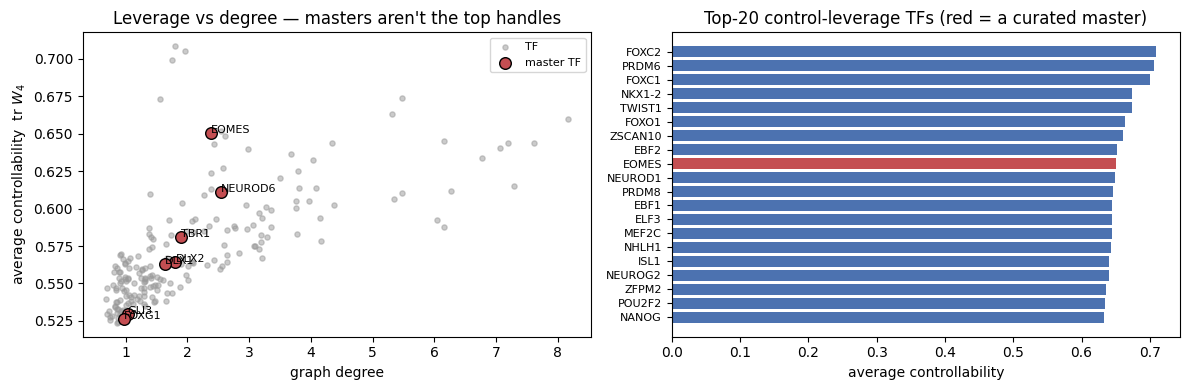


  committed jaxctrl top-8 by avg controllability: ['FOXC2', 'PRDM6', 'FOXC1', 'NKX1-2', 'TWIST1', 'FOXO1', 'ZSCAN10', 'EBF2']
  this run's top-8:                              ['FOXC2', 'PRDM6', 'FOXC1', 'NKX1-2', 'TWIST1', 'FOXO1', 'ZSCAN10', 'EBF2']


In [4]:
T = float(net_json["horizon"]) if (net_json and "horizon" in net_json) else 4.0
t0 = time.time()
avg_ctrl, grids, dt = avg_controllability_all(A_np, T, K=60)        # (n,) tr(W_i) for all single-node inputs
order = np.argsort(-avg_ctrl)
# modal controllability λ_min(W_i) for the top-20 by avg (cheap: 20 small eigendecomps)
mod_top = {}
for i in order[:20]:
    Wi = np.zeros((n, n))
    for Phi in grids:
        c = Phi[:, i]; Wi += np.outer(c, c)
    Wi *= dt
    mod_top[i] = float(np.linalg.eigvalsh((Wi + Wi.T) / 2)[0])
print(f"per-node Gramian sweep ({n} nodes, T={T}): {time.time()-t0:.1f}s")
drv = set(drivers_local)
print(f"\n  {'rank':>4}  {'TF':>10}  {'avg ctrl':>10}  {'modal ctrl':>12}  {'degree':>8}  driver?")
for r, i in enumerate(order[:20]):
    print(f"  {r+1:>4}  {kept_names[i]:>10}  {avg_ctrl[i]:>10.4f}  {mod_top[i]:>12.2e}  {deg[i]:>8.2f}  {'★' if i in drv else ''}")
# where do the master regulators rank?
ranks_of_drivers = {kept_names[i]: int(np.where(order == i)[0][0]) + 1 for i in drivers_local}
print(f"\n  master-regulator ranks by avg controllability (of {n}): "
      + ", ".join(f"{k}:{v}" for k, v in sorted(ranks_of_drivers.items(), key=lambda kv: kv[1])))

fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.0))
a0.scatter(deg, avg_ctrl, s=14, alpha=.5, color="#999", label="TF")
a0.scatter(deg[drivers_local], avg_ctrl[drivers_local], s=70, color="#C44E52", edgecolor="k", zorder=3, label="master TF")
for i in drivers_local: a0.annotate(kept_names[i], (deg[i], avg_ctrl[i]), fontsize=8)
a0.set_xlabel("graph degree"); a0.set_ylabel(f"average controllability  tr $W_{{{int(T)}}}$"); a0.set_title("Leverage vs degree — masters aren't the top handles"); a0.legend(fontsize=8)
top = order[:20]
a1.barh(range(20), avg_ctrl[top][::-1], color=["#C44E52" if i in drv else "#4C72B0" for i in top[::-1]])
a1.set_yticks(range(20)); a1.set_yticklabels([kept_names[i] for i in top[::-1]], fontsize=8)
a1.set_xlabel(f"average controllability"); a1.set_title("Top-20 control-leverage TFs (red = a curated master)")
fig.tight_layout(); plt.show()
if net_json and net_json.get("control_leverage_top20"):
    j_top = [d["tf"] for d in net_json["control_leverage_top20"][:8]]
    print(f"\n  committed jaxctrl top-8 by avg controllability: {j_top}")
    print(f"  this run's top-8:                              {[kept_names[i] for i in order[:8]]}")

## 4. Steer-to-target — the anatomical compiler, linear edition

Take $x_0$ = the TF state at early pseudotime and $x_f$ = the TF state at late pseudotime (from
`temporal_expression.npy`, z-scored over bins) and ask for the cheapest input that drives $x_0 \to
x_f$ over the horizon $T$, with three actuator sets: the **7 master TFs**, a **random equal-size
set**, and **full actuation** (every TF a handle). Watch two numbers per set: the minimum energy
$E^\star$, and $\lambda_{\min}(W_T)$ — when the Gramian's smallest eigenvalue is ≈ 0, the target
direction isn't in the reachable subspace and $E^\star$ is an ill-conditioned pseudo-inverse
artefact (so we report it as "uncontrollable" rather than a finite number). Then the LQR feedback
law and its cost-to-go, and the closed-loop trajectory of a few TFs converging to target. This is
the toy "desired anatomy in → intervention out" — the *linear* prototype of Lab 8's nonlinear
optimal control on the *learned* Hypergraph Neural ODE.

steer  x₀(early pseudotime) → x_f(late pseudotime)   over horizon T=4.0:
               input set   E* (min energy)    λ_min(W_T)
          master TFs (7)    uncontrollable     -1.51e-16
                random 7    uncontrollable     -1.20e-16
    full actuation (200)               587      3.59e-01



  LQR cost-to-go from x₀:  master-TF inputs 2.6e+03  (‖K‖=26.4)   |  full actuation 101  (‖K‖=128.1)


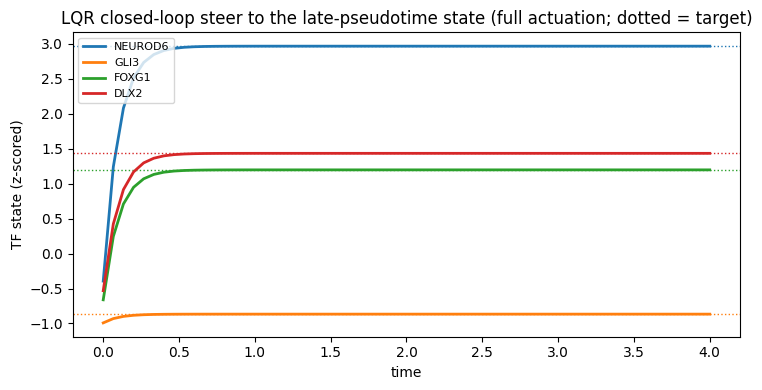


  committed jaxctrl run:  E*(full)=586  λ_min(full)=3.60e-01  |  LQR cost-to-go: master 2.6e+03, full 101
  (the master-TF set: λ_min ≈ -1.3e-07 ≈ 0  →  E* undefined; LQR still 'works' but with a huge cost-to-go — it just can't reach.)


In [5]:
steer_ok = False
if HAVE_REAL and temporal is not None and temporal.ndim == 2 and temporal.shape[0] >= 2 and tf_gene:
    idx = []
    ok = True
    for nm in kept_names:
        gi = tf_gene.get(nm)
        if gi is None or gi >= temporal.shape[1]: ok = False; break
        idx.append(int(gi))
    if ok:
        E = temporal[:, np.asarray(idx)]
        E = (E - E.mean(0, keepdims=True)) / (E.std(0, keepdims=True) + 1e-6)
        x0, xf = E[0], E[-1]
        # precompute the expm grid once (shared across input sets)
        grids_T, dt_T, PhiT = _expm_grid(A_np, T, K=60)
        rand_local = sorted(rng.choice(n, size=len(drivers_local), replace=False).tolist())
        sets = {"master TFs (7)": B_drivers,
                f"random {len(drivers_local)}": np.eye(n)[:, rand_local],
                "full actuation (200)": np.eye(n)}
        print(f"steer  x₀(early pseudotime) → x_f(late pseudotime)   over horizon T={T}:")
        print(f"  {'input set':>22}  {'E* (min energy)':>16}  {'λ_min(W_T)':>12}")
        for nm, Bsel in sets.items():
            e, lam, _ = min_energy(A_np, Bsel, x0, xf, T, _grids=(grids_T, dt_T, PhiT))
            print(f"  {nm:>22}  {('uncontrollable' if e is None else f'{e:.3g}'):>16}  {lam:>12.2e}")
        # LQR steer-to-target on y = x - xf
        Q = np.eye(n); y0 = x0 - xf
        K_key, X_key = lqr(A_np, B_drivers, Q, 1e-2 * np.eye(len(drivers_local)))
        K_full, X_full = lqr(A_np, np.eye(n), Q, 1e-2 * np.eye(n))
        print(f"\n  LQR cost-to-go from x₀:  master-TF inputs {y0 @ X_key @ y0:.3g}  (‖K‖={np.linalg.norm(K_key):.1f})"
              f"   |  full actuation {y0 @ X_full @ y0:.3g}  (‖K‖={np.linalg.norm(K_full):.1f})")
        # closed-loop trajectory under full actuation (the well-posed case): ẏ = (A - K)y, x = y + xf
        Acl = A_np - K_full
        ts = np.linspace(0, T, 61)
        Y = np.stack([sla.expm(Acl * t) @ y0 for t in ts])          # (61, n)
        Xtraj = Y + xf[None, :]
        pick = drivers_local[:4]
        fig, ax = plt.subplots(figsize=(7.6, 4.0))
        for j in pick:
            ax.plot(ts, Xtraj[:, j], lw=2, label=kept_names[j])
            ax.axhline(xf[j], ls=":", color=ax.lines[-1].get_color(), lw=1)
        ax.set_xlabel("time"); ax.set_ylabel("TF state (z-scored)"); ax.legend(fontsize=8)
        ax.set_title("LQR closed-loop steer to the late-pseudotime state (full actuation; dotted = target)")
        fig.tight_layout(); plt.show()
        steer_ok = True
        if net_json and net_json.get("steer_to_target", {}).get("available"):
            sj = net_json["steer_to_target"]
            print(f"\n  committed jaxctrl run:  E*(full)={sj.get('energy_full_inputs'):.3g}  λ_min(full)={sj.get('gramian_min_eig_full'):.2e}"
                  f"  |  LQR cost-to-go: master {sj.get('lqr_cost_to_go_key_tf'):.3g}, full {sj.get('lqr_cost_to_go_full'):.3g}")
            print(f"  (the master-TF set: λ_min ≈ {sj.get('gramian_min_eig_key_tf'):.1e} ≈ 0  →  E* undefined; LQR still 'works' but with a huge cost-to-go — it just can't reach.)")
if not steer_ok:
    print("[note] temporal_expression.npy / tf_gene_indices.json not usable here — see figures/network_control_results.json"
          " for the committed steer-to-target result, or run scripts/benchmark_network_control.py.")

## 5. What this is — and the three `jaxctrl` worked examples

- **Linear is the *local* story.** The TF network here is a linear surrogate ($A = -L$ of a sparse
  co-regulation graph); LQR and minimum-energy control are exact *for that linearisation*. The real
  regulome is nonlinear (Hill kinetics, saturation, multistability — Lab 1, Lab 5), so the honest
  pipeline is **linearise (or fit a SINDy/Koopman surrogate) → run this toolkit → warm-start a
  nonlinear optimiser** — which is exactly what Lab 8 (`scripts/benchmark_anatomical_compiler.py`)
  does on the *learned* Hypergraph Neural ODE.
- **Controllability ⇔ observability (Lab 7).** Same matrices, transposed. "Not controllable from
  the masters" and "not observable from the masters" are one fact; the SBI ridge (Lab 8) is its
  statistical shadow. A structural-identifiability check (Lab 7) belongs *before* you trust any
  mechanistic reduced model you then control.
- **Leverage ≠ identity (Labs 2–5).** The TFs that *define* a cell type (the master regulators) are
  not the TFs you'd *push* to move it cheaply — control leverage is a property of where a node sits
  in the dynamics, not of how identity-defining it is. (Yan et al. 2017: there's also a
  control–robustness trade-off — the cheapest-to-control configurations are often the most fragile.)

The full, *nonlinear* / GRN-scale versions live in the **`jaxctrl`** repo
([github.com/m9h/jaxctrl](https://github.com/m9h/jaxctrl)) — the three worked examples this lab is
the bridge to:

| notebook | what it does |
|---|---|
| `examples/repressilator_control_demo.py` | the 3-gene oscillator (Lab 1's repressilator): linearise → check controllability → LQR → **quench the *nonlinear* flow** with the LQR input → `jax.grad` the cost w.r.t. a kinetic parameter |
| `examples/irma_sindy_lqr.ipynb` | a GRN end-to-end: simulate the IRMA-topology Hill-ODE → fit a **`SINDyOptimizer` linear surrogate** → controllability → LQR "drug input" → sensitivity analysis |
| `examples/grn_hypergraph_drivers.ipynb` | GRN-as-hypergraph: `minimum_driver_nodes`, `controllability_profile`, the `control_energy` landscape, `HypergraphControlSystem` + LQR — "which TFs must I perturb to control this regulon?" |

## 6. Exercises

**(a) Linearise the Lab-5 ODE and control *that*.** Take the fitted Neural ODE $\dot x = f_\theta(x)$
from [Lab 5](05_hypergraph_neural_odes.ipynb), compute its Jacobian $A = \partial f_\theta/\partial
x$ at the early-pseudotime state with `jax.jacfwd`, build $B$ from a chosen handle set, and run §2–§4
on $(A,B)$. Do you reach the same conclusion (masters under-control the network)? Does the LQR input,
applied to the *nonlinear* flow, actually land near the late-pseudotime basin?

**(b) The SINDy/Koopman route.** Instead of $A = -L$, fit a *linear surrogate* $\dot z = Az + Bu$ to
the organoid latent trajectory (least-squares on finite differences, à la SINDy with a linear
library; or a Koopman/DMD fit) and check its controllability. How much does the conclusion depend on
which linearisation you pick? (This is `jaxctrl/examples/irma_sindy_lqr.ipynb`'s move.)

**(c) Which directions are unreachable?** Compute the left nullspace of the controllability matrix
$\mathcal C$ for the master-TF inputs — the $n - \operatorname{rank}\mathcal C$ directions you can't
move (a lot: most of the 200). Equivalently, look at the eigenvectors of $W_T$ with near-zero
eigenvalue. Project them onto the TF basis — which TFs dominate the *unreachable* subspace? Do they
line up with the diffuse, low-MII modules of [Lab 4](04_modularity_identifiability.ipynb) and the
unobservable directions of [Lab 7](07_structural_identifiability.ipynb)?

**(d) Minimum driver nodes on the *hypergraph*.** The Liu–Slotine–Barabási matching gives a count
for the linearised graph; `jaxctrl.minimum_driver_nodes(hgx.from_incidence(H))` does the
hypergraph version directly (the committed json left it `null` because `hgx` wasn't available in that
run). Compute it. How does the minimal control set compare to the curated master regulators (overlap?
size?) — and to the high-leverage TFs of §3?

**(e) The control–robustness trade-off (Yan et al. 2017).** The cheapest single handles (§3) — are
they also the ones whose removal most disconnects the network (degree? betweenness? algebraic
connectivity drop)? Plot leverage vs a robustness proxy; is there a Pareto front?

Starters for (a) and (d):

In [6]:
# --- Exercise (a) starter: linearise a fitted (or hand-written) ODE and control it -----------
# A toy stand-in for the Lab-5 fitted field, so the starter runs standalone:
def f_demo(x, W=np.array([[-0.4, 0.9, 0.0], [-0.9, -0.4, 0.0], [0.2, 0.0, -0.7]])):
    return W @ np.tanh(x) - 0.1 * x
x_star = np.zeros(3)
A_lin = np.array([[ (f_demo(x_star + 1e-5*np.eye(3)[k])[i] - f_demo(x_star - 1e-5*np.eye(3)[k])[i]) / 2e-5
                    for k in range(3)] for i in range(3)])           # finite-difference Jacobian
B_lin = np.eye(3)[:, [0]]                                            # actuate gene 0 only
print(f"linearised toy field:  A ≈\n{A_lin.round(3)}")
print(f"  ctrb rank from gene 0 alone: {ctrb_rank(A_lin, B_lin)}/3  (controllable = {is_controllable(A_lin, B_lin)})")
Kd, Xd = lqr(A_lin, B_lin, np.eye(3), np.array([[1.0]]))
print(f"  LQR gain {Kd.ravel().round(3)};  cost-to-go from x=[1,1,1]: {(np.ones(3) @ Xd @ np.ones(3)):.3f}")
print("  → your turn (a): replace f_demo with the Lab-5 f_θ, use jax.jacfwd for A, then steer the *nonlinear* flow with u=-Ky.")

# --- Exercise (d) starter: minimum driver nodes ----------------------------------------------
print(f"\nmin driver nodes (structural, this linearised TF network): {min_driver_nodes(A_np)} / {n}")
try:
    import hgx
    print("  hgx importable — for the hypergraph version:")
    print("    hg = hgx.from_incidence(jnp.asarray(incidence[:, kept]));  jaxctrl.minimum_driver_nodes(hg)")
    print("    then compare the returned driver set with the curated master TFs and the §3 high-leverage TFs.")
except Exception:
    print("  [note] hgx not importable here — see scripts/benchmark_network_control.py for the hgx.minimum_driver_nodes path.")

linearised toy field:  A ≈
[[-0.5  0.9  0. ]
 [-0.9 -0.5  0. ]
 [ 0.2  0.  -0.8]]
  ctrb rank from gene 0 alone: 3/3  (controllable = True)
  LQR gain [ 0.689 -0.081  0.047];  cost-to-go from x=[1,1,1]: 2.164
  → your turn (a): replace f_demo with the Lab-5 f_θ, use jax.jacfwd for A, then steer the *nonlinear* flow with u=-Ky.

min driver nodes (structural, this linearised TF network): 1 / 200
  hgx importable — for the hypergraph version:
    hg = hgx.from_incidence(jnp.asarray(incidence[:, kept]));  jaxctrl.minimum_driver_nodes(hg)
    then compare the returned driver set with the curated master TFs and the §3 high-leverage TFs.


## Recap & where this sits

- **Network control** turns the regulome into a steerable plant $\dot x = Ax + Bu$ and asks the five
  questions: controllability (Kalman rank), the Gramian (average vs modal controllability), minimum-
  energy control, LQR, and the minimum driver-node count (Liu–Slotine–Barabási matching) — all short
  to implement (we did, in pure JAX/SciPy; `jaxctrl` is the library version).
- The headline: **the curated master regulators don't control the TF network** (Kalman rank far
  below 200 — ≈9 at float32 tolerance, ≈30 at float64 — from the 7 key TFs) — the *dual* of Lab
  7's "not observable from the masters", and the structural reason Lab 8's SBI posterior is a
  ridge. (Note structural controllability ≠ exact: the Liu–Slotine–Barabási *generic* count is
  $N_D\approx1$ for this dense graph, but our $A$ is a Laplacian — non-generic weights — so the
  *actual* rank is far below what genericity promises.) **Control leverage ≠ identity**: the
  highest-leverage single TFs are mostly *not* the developmental masters (only EOMES makes the top
  20 — FOXC2/PRDM6/FOXC1 lead, reproducing the committed run exactly). And a single TF's *modal*
  controllability is ≈ 0 — you need a *set* (or full actuation) to reach a generic target; with full
  actuation the early→late steer costs $E^\star \approx 586$ / LQR cost-to-go $\approx 101$, vs
  effectively-uncontrollable from the masters alone.
- **Next:** [Lab 7](07_structural_identifiability.ipynb) — is the *mechanistic* reduction you'd
  control even *identifiable*? (the symbolic pre-condition) — and **Lab 8 — the anatomical compiler**:
  nonlinear optimal control on the *learned* Hypergraph Neural ODE (`diffrax` adjoints + Adam, warm-
  started from this lab's LQR) — "target tissue state in → TF-actuation schedule out".
- Pipeline: `scripts/benchmark_network_control.py` (this lab's linear network control →
  `figures/network_control_results.json`), `scripts/benchmark_anatomical_compiler.py` (Lab 8). The
  nonlinear / SINDy / hypergraph-driver worked examples: the three `jaxctrl/examples/*` notebooks
  (`repressilator_control_demo.py`, `irma_sindy_lqr.ipynb`, `grn_hypergraph_drivers.ipynb`).